In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1: Install Dependencies (OPTIMIZED FOR T4 GPU)
# ═══════════════════════════════════════════════════════════════════════════

print("Installing libraries...\n")

# Core transformers (stable version)
!pip install -q transformers==4.38.0 accelerate==0.27.2

# Evaluation libraries
!pip install -q nltk rouge-score sacrebleu textstat

# Image processing
!pip install -q scipy pillow opencv-python

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print(" All libraries installed!")
print(" Using float16 + CPU offloading for 8B/7B models")


Installing libraries...

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 74.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.6 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.38.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.8 MB/s eta 0:00:0000:01
 All libraries installed!
 Using float16 + CPU offloading for 8B/7B models


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2: System Check
# ═══════════════════════════════════════════════════════════════════════

import torch
import sys

print("="*70)
print("SYSTEM CONFIGURATION")
print("="*70)
print(f"✓ Python version: {sys.version.split()[0]}")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("  NO GPU! Some models will not work.")
    print("   Go to Settings → Accelerator → GPU T4")

print("="*70)

SYSTEM CONFIGURATION
✓ Python version: 3.12.12
✓ PyTorch version: 2.8.0+cu126
✓ CUDA available: True
✓ GPU: Tesla P100-PCIE-16GB
✓ GPU Memory: 15.9 GB


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3: Setup Project Files
# ═══════════════════════════════════════════════════════════════════════

import sys
import os
from pathlib import Path
import shutil

print("Setting up project files...\n")

DATASET_PATH = "/kaggle/input/xai-chest-x-ray-project-final-year/kaggle-upload"
WORK_DIR = "/kaggle/working"

# Copy src_v2
src_source = Path(f"{DATASET_PATH}/src_v2")
src_dest = Path(f"{WORK_DIR}/src_v2")

if src_dest.exists():
    shutil.rmtree(src_dest)
shutil.copytree(src_source, src_dest)
sys.path.insert(0, WORK_DIR)

print(f"Code copied: {len(list(src_dest.glob('*.py')))} files")

# Fix imports
for py_file in src_dest.glob("*.py"):
    content = py_file.read_text()
    content = content.replace("from .config import", "from src_v2.config import")
    content = content.replace("from .xai_enhanced import", "from src_v2.xai_enhanced import")
    content = content.replace("from .behavior_extractor import", "from src_v2.behavior_extractor import")
    py_file.write_text(content)

print("Imports fixed!")

# Store paths
MODEL_PATH = Path(f"{DATASET_PATH}/models/efficientNet.pth")
SAMPLE_PATH = Path(f"{DATASET_PATH}/Test-Samples/sample-2.jpg")

if MODEL_PATH.exists():
    print(f"Model: {MODEL_PATH.stat().st_size / 1024**2:.1f} MB")
if SAMPLE_PATH.exists():
    print(f"Image: {SAMPLE_PATH.name}")

print("\n" + "="*70)
print(" Setup complete!")
print("="*70)



Setting up project files...

Code copied: 9 files
Imports fixed!
Model: 269.8 MB
Image: sample-2.jpg

 Setup complete!


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4: Load Modules
# ═══════════════════════════════════════════════════════════════════════════

print("Loading modules...\n")

from src_v2.config import *
from src_v2.xai_enhanced import EnhancedGradCAM
from src_v2.behavior_extractor import ModelBehaviorExtractor

print("All modules loaded!")


Loading modules...

Using device: cuda
Configuration loaded successfully!
All modules loaded!


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5: Evaluation Functions
# ═══════════════════════════════════════════════════════════════════════════

import time
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import textstat
import re

print("Setting up evaluation...\n")

class NLPEvaluator:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        self.smoothing = SmoothingFunction()
        self.medical_terms = [
            'pneumothorax', 'pleural', 'lung', 'thorax', 'chest', 'pulmonary',
            'atelectasis', 'consolidation', 'effusion', 'infiltration',
            'cardiomegaly', 'cardiac', 'mediastinum', 'diaphragm'
        ]

    def evaluate_explanation(self, text, reference, gen_time, gpu_mem=0):
        results = {}

        # Readability
        results['flesch_reading_ease'] = textstat.flesch_reading_ease(text)
        results['flesch_kincaid_grade'] = textstat.flesch_kincaid_grade(text)
        results['word_count'] = len(text.split())
        results['avg_sentence_length'] = textstat.avg_sentence_length(text)

        # Medical terms
        text_lower = text.lower()
        medical_count = sum(1 for term in self.medical_terms if term in text_lower)
        results['medical_terms_count'] = medical_count
        results['medical_term_density'] = medical_count / max(1, results['word_count']) * 100

        # Performance
        results['generation_time'] = gen_time
        results['gpu_memory_gb'] = gpu_mem
        results['words_per_second'] = results['word_count'] / max(0.1, gen_time)

        # Overall score
        readability_score = min(100, max(0, results['flesch_reading_ease'])) / 100
        medical_score = min(1.0, medical_count / 10)
        speed_score = min(1.0, 10 / max(0.1, gen_time))

        results['overall_quality'] = (
            readability_score * 0.3 + medical_score * 0.4 + speed_score * 0.3
        )

        return results

    def print_evaluation(self, results, model_name, layer):
        print(f"\n{'─'*70}")
        print(f"EVALUATION: {model_name} - {layer.upper()}")
        print(f"{'─'*70}")
        print(f"\nText: {results['word_count']} words, {results['avg_sentence_length']:.1f} avg/sentence")
        print(f"Readability: {results['flesch_reading_ease']:.1f} (Grade {results['flesch_kincaid_grade']:.1f})")
        print(f"Medical: {results['medical_terms_count']} terms ({results['medical_term_density']:.2f}%)")
        print(f"Speed: {results['generation_time']:.2f}s ({results['words_per_second']:.1f} w/s)")
        if results['gpu_memory_gb'] > 0:
            print(f"GPU: {results['gpu_memory_gb']:.2f} GB")
        print(f"\nOverall Quality: {results['overall_quality']:.3f}")
        print(f"{'─'*70}")

evaluator = NLPEvaluator()
print("Evaluator ready!")


Setting up evaluation...

Evaluator ready!


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5B: Structured Prompt Generators (ADD THIS NEW CELL)
# ═══════════════════════════════════════════════════════════════════════════

def generate_clinician_prompt(disease, confidence, behavior):
    """
    Creates structured prompt for clinician-level explanations.
    Forces consistent output format across all models.
    """
    regions = behavior.get("anatomical_regions", [])
    spatial = behavior.get("spatial_analysis", {})
    
    if regions:
        region_details = []
        for r in regions[:3]:
            region_name = r['name'].replace('_', ' ').title()
            attention = r['attention_score'] * 100
            region_details.append(f"{region_name} ({attention:.0f}% attention)")
        regions_text = ", ".join(region_details)
    else:
        regions_text = "No specific anatomical regions identified"
    
    pattern = "focal abnormality" if spatial.get("is_focal") else "diffuse pattern"
    coverage = spatial.get("attention_percentage", 0)
    
    prompt = f"""You are an expert radiologist writing a technical report. Follow this exact structure:

**FINDING SUMMARY:**
- Primary diagnosis: {disease}
- Model confidence: {confidence*100:.1f}%
- Pattern type: {pattern}

**MODEL ATTENTION ANALYSIS:**
The AI diagnostic model focused on the following anatomical regions:
{regions_text}
Total coverage area: {coverage:.1f}% of the thoracic cavity

**CLINICAL INTERPRETATION:**
Provide a detailed technical analysis (100-120 words) explaining:
1. What this finding means anatomically
2. Why the model focused on these specific regions
3. The radiological significance of the {pattern}

**DIFFERENTIAL CONSIDERATIONS:**
List 2-3 differential diagnoses and key distinguishing features.

Write in medical terminology appropriate for radiologists. Be specific and technical."""

    return prompt


def generate_patient_prompt(disease, confidence, behavior):
    """
    Creates friendly prompt for patient-level explanations.
    Maintains warm, supportive tone.
    """
    regions = behavior.get("anatomical_regions", [])
    
    if regions:
        region_names = [r['name'].replace('_', ' ').lower() for r in regions[:2]]
        if len(region_names) == 1:
            location_text = f"the {region_names[0]} area"
        else:
            location_text = f"the {region_names[0]} and {region_names[1]} areas"
    else:
        location_text = "certain areas of your chest"
    
    prompt = f"""You are a caring doctor explaining X-ray results to a patient. Write in simple, clear language.

The X-ray shows signs of {disease.lower()} affecting {location_text}.

Please explain this to the patient in 120-150 words:

1. **What it means:** Explain {disease.lower()} in simple terms (like talking to a friend)
2. **What we saw:** Mention that the AI system detected this in {location_text}
3. **What happens next:** Briefly mention common treatment or next steps
4. **Reassurance:** End with a supportive, calming statement

Use these guidelines:
- Write at 8th-grade reading level
- Avoid medical jargon (or explain it simply)
- Use "you" and "your" to make it personal
- Be warm, supportive, and honest
- Don't scare the patient unnecessarily

Do NOT include diagnosis confidence percentages or technical terms."""

    return prompt


print("Structured prompt generators ready!")
print("   • Clinician: 4-section technical format")
print("   • Patient: Friendly, supportive tone")


Structured prompt generators ready!
   • Clinician: 4-section technical format
   • Patient: Friendly, supportive tone


# MODEL IMPLEMENTATIONS AND GENERATION

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6: Load ResNet50 Model
# ═══════════════════════════════════════════════════════════════════════════

import torch.nn as nn
from torchvision import models

print("Loading ResNet50...\n")

class ChestXRayModel(nn.Module):
    def __init__(self, num_classes=14):
        super(ChestXRayModel, self).__init__()
        self.backbone = models.resnet50(pretrained=False)
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

model = ChestXRayModel(num_classes=14).to('cuda')
checkpoint = torch.load(str(MODEL_PATH), map_location='cuda')
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

print(f"ResNet50 ready ({sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params)")



Loading ResNet50...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet50 ready (23.5M params)


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7: Flan-T5-Base (UPDATED WITH STRUCTURED PROMPTS)
# ═══════════════════════════════════════════════════════════════════════════

from transformers import T5Tokenizer, T5ForConditionalGeneration

print("Loading Flan-T5-Base...\n")

flant5_tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
flant5_model = T5ForConditionalGeneration.from_pretrained(
    "google/flan-t5-base",
    torch_dtype=torch.float32,
    device_map="cpu"
)

print("Flan-T5 loaded (250M params, CPU)")

def generate_flant5_explanation(disease, confidence, behavior, layer="clinician"):
    """Generate explanation using structured prompts"""
    
    # Use universal prompt generators
    if layer == "clinician":
        prompt = generate_clinician_prompt(disease, confidence, behavior)
    else:
        prompt = generate_patient_prompt(disease, confidence, behavior)
    
    inputs = flant5_tokenizer(
        prompt, 
        return_tensors="pt", 
        max_length=512, 
        truncation=True
    ).to("cpu")
    
    start_time = time.time()
    with torch.no_grad():
        outputs = flant5_model.generate(
            **inputs,
            max_new_tokens=300,  # Increased for structured output
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            num_beams=2,
            repetition_penalty=1.3,      # ← INCREASED to prevent repetition
            no_repeat_ngram_size=3,      # ← ADDED to block repeated phrases
            early_stopping=True
        )
    gen_time = time.time() - start_time
    
    explanation = flant5_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Clean up any remaining artifacts
    explanation = explanation.strip()
    
    return explanation, gen_time

print("Flan-T5 generator ready (with structured prompts)!")


Loading Flan-T5-Base...



/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Flan-T5 loaded (250M params, CPU)
Flan-T5 generator ready (with structured prompts)!


In [9]:
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 12.6 MB/s eta 0:00:0000:010:01


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8: BioGPT-Large (UPDATED WITH STRUCTURED PROMPTS)
# ═══════════════════════════════════════════════════════════════════════════

from transformers import BioGptTokenizer, BioGptForCausalLM

print("Loading BioGPT-Large...\n")

biogpt_tokenizer = BioGptTokenizer.from_pretrained("microsoft/biogpt-large")
biogpt_model = BioGptForCausalLM.from_pretrained(
    "microsoft/biogpt-large",
    torch_dtype=torch.float32,
    device_map="cpu"
)

if biogpt_tokenizer.pad_token is None:
    biogpt_tokenizer.pad_token = biogpt_tokenizer.eos_token

print("BioGPT loaded (355M params, CPU - Biomedical)")

def generate_biogpt_explanation(disease, confidence, behavior, layer="clinician"):
    """Generate explanation using structured prompts"""
    
    # Use universal prompt generators
    if layer == "clinician":
        prompt = generate_clinician_prompt(disease, confidence, behavior)
    else:
        prompt = generate_patient_prompt(disease, confidence, behavior)
    
    # BioGPT needs shorter prompt (it's completion-based)
    # Add instruction prefix
    prompt = f"Generate medical explanation:\n\n{prompt}\n\nResponse:"
    
    inputs = biogpt_tokenizer(
        prompt, 
        return_tensors="pt", 
        max_length=400,  # Increased
        truncation=True
    ).to("cpu")
    
    start_time = time.time()
    with torch.no_grad():
        outputs = biogpt_model.generate(
            **inputs,
            max_new_tokens=350,              # Increased for full response
            min_length=150,                  # ← ADDED to force longer output
            temperature=0.8,
            top_p=0.92,
            do_sample=True,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,          # ← ADDED
            pad_token_id=biogpt_tokenizer.eos_token_id,
            eos_token_id=biogpt_tokenizer.eos_token_id
        )
    gen_time = time.time() - start_time
    
    full_text = biogpt_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract only the generated response (remove prompt)
    if "Response:" in full_text:
        explanation = full_text.split("Response:")[-1].strip()
    else:
        explanation = full_text.replace(prompt, "").strip()
    
    # Clean up incomplete sentences
    if explanation and explanation[-1] not in '.!?':
        last_period = explanation.rfind('.')
        if last_period > len(explanation) * 0.6:
            explanation = explanation[:last_period + 1]
    
    return explanation, gen_time

print("BioGPT generator ready (with structured prompts + min_length)!")


Loading BioGPT-Large...



tokenizer_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/658 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/6.29G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

BioGPT loaded (355M params, CPU - Biomedical)
BioGPT generator ready (with structured prompts + min_length)!


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9: Phi-2 Generator Function (UPDATED)
# ═══════════════════════════════════════════════════════════════════════════

print("  Skipping model loading in this cell")
print("   (Will load sequentially in Cell 13)")

def generate_llama3_explanation(disease, confidence, behavior, layer="clinician"):
    """Generate explanation using Phi-2 (Instruct format)"""
    
    # Use universal prompt generators
    if layer == "clinician":
        user_prompt = generate_clinician_prompt(disease, confidence, behavior)
    else:
        user_prompt = generate_patient_prompt(disease, confidence, behavior)
    
    # Phi-2 uses Instruct format (not chat template)
    formatted = f"Instruct: {user_prompt}\nOutput:"
    
    inputs = llama_tokenizer(
        formatted,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    ).to('cuda')
    
    start_time = time.time()
    start_mem = torch.cuda.memory_allocated() / 1024**3
    
    with torch.no_grad():
        outputs = llama_model.generate(
            **inputs,
            max_new_tokens=350,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.15,
            pad_token_id=llama_tokenizer.pad_token_id,
            eos_token_id=llama_tokenizer.eos_token_id,
        )
    
    gen_time = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated() / 1024**3
    
    full_text = llama_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract response (remove prompt)
    if "Output:" in full_text:
        explanation = full_text.split("Output:")[-1].strip()
    else:
        explanation = full_text.replace(formatted, "").strip()
    
    # Clean
    while explanation and explanation[0] in ['.', '\n', ' ']:
        explanation = explanation[1:]
    
    # Remove incomplete last sentence
    if explanation and explanation[-1] not in '.!?':
        last_period = explanation.rfind('.')
        if last_period > len(explanation) * 0.6:
            explanation = explanation[:last_period + 1]
    
    torch.cuda.reset_peak_memory_stats()
    return explanation, gen_time, peak_mem

print(" Phi-2 generator function ready!")


  Skipping model loading in this cell
   (Will load sequentially in Cell 13)
 Phi-2 generator function ready!


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9: LLaMA 3 Generator Function (UPDATED WITH STRUCTURED PROMPTS)
# ═══════════════════════════════════════════════════════════════════════════

print("  Skipping LLaMA 3 loading in this cell")
print("   (Will load sequentially in Cell 13)")

def generate_llama3_explanation(disease, confidence, behavior, layer="clinician"):
    """Generate explanation using structured prompts"""
    
    # Use universal prompt generators
    if layer == "clinician":
        user_prompt = generate_clinician_prompt(disease, confidence, behavior)
    else:
        user_prompt = generate_patient_prompt(disease, confidence, behavior)
    
    messages = [
        {"role": "system", "content": "You are an expert medical AI assistant specializing in radiology."},
        {"role": "user", "content": user_prompt}
    ]
    
    formatted = llama_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = llama_tokenizer(
        formatted,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    ).to('cuda')
    
    start_time = time.time()
    start_mem = torch.cuda.memory_allocated() / 1024**3
    
    with torch.no_grad():
        outputs = llama_model.generate(
            **inputs,
            max_new_tokens=350,  # Increased for structured output
            temperature=0.7,
            top_p=0.92,
            do_sample=True,
            repetition_penalty=1.15,
            pad_token_id=llama_tokenizer.pad_token_id,
            eos_token_id=llama_tokenizer.eos_token_id,
        )
    
    gen_time = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated() / 1024**3
    
    full_text = llama_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract response
    explanation = full_text
    for marker in ["assistant\n\n", "assistant\n", "Assistant:"]:
        if marker in full_text:
            explanation = full_text.split(marker)[-1].strip()
            break
    
    if explanation == full_text:
        explanation = full_text.replace(formatted, "").strip()
    
    # Clean
    while explanation and explanation[0] in ['.', '\n', ' ']:
        explanation = explanation[1:]
    
    torch.cuda.reset_peak_memory_stats()
    return explanation, gen_time, peak_mem

print(" LLaMA 3 generator function ready!")


  Skipping LLaMA 3 loading in this cell
   (Will load sequentially in Cell 13)
 LLaMA 3 generator function ready!


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10: Qwen2 Generator Function (UPDATED WITH STRUCTURED PROMPTS)
# ═══════════════════════════════════════════════════════════════════════════

print("  Skipping Qwen2 loading in this cell")
print("   (Will load sequentially in Cell 13)")

def generate_qwen2_explanation(disease, confidence, behavior, layer="clinician"):
    """Generate explanation using structured prompts"""
    
    # Use universal prompt generators
    if layer == "clinician":
        user_prompt = generate_clinician_prompt(disease, confidence, behavior)
    else:
        user_prompt = generate_patient_prompt(disease, confidence, behavior)
    
    messages = [
        {"role": "system", "content": "You are an expert medical AI assistant specializing in radiology."},
        {"role": "user", "content": user_prompt}
    ]
    
    formatted = qwen_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    
    inputs = qwen_tokenizer(
        formatted,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    ).to('cuda')
    
    start_time = time.time()
    start_mem = torch.cuda.memory_allocated() / 1024**3
    
    with torch.no_grad():
        outputs = qwen_model.generate(
            **inputs,
            max_new_tokens=350,  # Increased for structured output
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=qwen_tokenizer.pad_token_id,
            eos_token_id=qwen_tokenizer.eos_token_id,
        )
    
    gen_time = time.time() - start_time
    peak_mem = torch.cuda.max_memory_allocated() / 1024**3
    
    full_text = qwen_tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    # Extract response
    explanation = full_text
    for marker in ["assistant\n\n", "assistant\n", "Assistant:"]:
        if marker in full_text:
            explanation = full_text.split(marker)[-1].strip()
            break
    
    if explanation == full_text:
        explanation = full_text.replace(formatted, "").strip()
    
    # Clean
    while explanation and explanation[0] in ['.', '\n', ' ']:
        explanation = explanation[1:]
    
    torch.cuda.reset_peak_memory_stats()
    return explanation, gen_time, peak_mem

print(" Qwen2 generator function ready!")


  Skipping Qwen2 loading in this cell
   (Will load sequentially in Cell 13)
 Qwen2 generator function ready!


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 11: Process X-Ray Image
# ═══════════════════════════════════════════════════════════════════════════

from PIL import Image
from torchvision import transforms
import numpy as np
import cv2

print("="*70)
print("PROCESSING CHEST X-RAY")
print("="*70)

# Load and preprocess
img = Image.open(SAMPLE_PATH).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
img_tensor = transform(img).unsqueeze(0).to('cuda')

print(f"\nImage loaded: {img.size} → {img_tensor.shape}")

# Predict
print(f"\n{'─'*70}")
print("STEP 1: MODEL PREDICTION")
print(f"{'─'*70}")

with torch.no_grad():
    logits = model(img_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

LABEL_NAMES = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Effusion", "Emphysema", "Fibrosis", "Hernia",
    "Infiltration", "Mass", "Nodule", "Pleural_Thickening",
    "Pneumonia", "Pneumothorax"
]

top_indices = np.argsort(probs)[::-1][:5]
print("\nTop 5 Predictions:")
for idx in top_indices:
    status = "✓" if probs[idx] > 0.5 else "○"
    print(f"   {status} {LABEL_NAMES[idx]:20s}: {probs[idx]*100:5.1f}%")

top_disease_idx = top_indices[0]
top_disease = LABEL_NAMES[top_disease_idx]
top_confidence = probs[top_disease_idx]

print(f"\nTarget: {top_disease} ({top_confidence*100:.1f}%)")

# Generate Grad-CAM
print(f"\n{'─'*70}")
print("STEP 2: GRAD-CAM GENERATION")
print(f"{'─'*70}")

# Fix float16 issue
xai_file = Path("/kaggle/working/src_v2/xai_enhanced.py")
if xai_file.exists():
    content = xai_file.read_text()
    if "cam.astype(np.float32)" not in content:
        content = content.replace(
            "from scipy.ndimage import gaussian_filter\n        cam = gaussian_filter(cam, sigma=2)",
            "from scipy.ndimage import gaussian_filter\n        cam = cam.astype(np.float32)\n        cam = gaussian_filter(cam, sigma=2)"
        )
        xai_file.write_text(content)
        if 'src_v2.xai_enhanced' in sys.modules:
            del sys.modules['src_v2.xai_enhanced']
        from src_v2.xai_enhanced import EnhancedGradCAM

gradcam = EnhancedGradCAM(model, target_layer="backbone.layer4")
heatmap = gradcam.generate_cam(img_tensor, top_disease_idx, device='cuda')

print(f"Heatmap: {heatmap.shape}, peak={heatmap.max():.3f}")

# Extract behavior
print(f"\n{'─'*70}")
print("STEP 3: BEHAVIOR EXTRACTION")
print(f"{'─'*70}")

behavior_extractor = ModelBehaviorExtractor()
behavior = behavior_extractor.extract_complete_behavior(
    predictions={top_disease: float(top_confidence)},
    heatmap=heatmap,
    all_probabilities=probs
)

spatial = behavior["spatial_analysis"]
regions = behavior["anatomical_regions"]

print(f"Behavior extracted:")
print(f"   Coverage: {spatial['attention_percentage']:.1f}%")
print(f"   Pattern: {'Focal' if spatial['is_focal'] else 'Diffuse'}")
if regions:
    print(f"   Top: {regions[0]['name']} ({regions[0]['attention_score']*100:.0f}%)")

print("\n" + "="*70)
print("READY FOR NLP GENERATION")
print("="*70)



PROCESSING CHEST X-RAY

Image loaded: (390, 320) → torch.Size([1, 3, 224, 224])

──────────────────────────────────────────────────────────────────────
STEP 1: MODEL PREDICTION
──────────────────────────────────────────────────────────────────────

Top 5 Predictions:
   ✓ Pneumothorax        :  84.7%
   ✓ Atelectasis         :  61.7%
   ○ Infiltration        :  14.9%
   ○ Nodule              :   5.7%
   ○ Edema               :   5.6%

Target: Pneumothorax (84.7%)

──────────────────────────────────────────────────────────────────────
STEP 2: GRAD-CAM GENERATION
──────────────────────────────────────────────────────────────────────
 Hooks registered on: backbone.layer4
Heatmap: (7, 7), peak=1.000

──────────────────────────────────────────────────────────────────────
STEP 3: BEHAVIOR EXTRACTION
──────────────────────────────────────────────────────────────────────
Behavior extracted:
   Coverage: 20.4%
   Pattern: Focal
   Top: cardiac (87%)

READY FOR NLP GENERATION


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 12: Generate ALL Explanations (Part 1: CPU Models)
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("GENERATING EXPLANATIONS - CPU MODELS")
print("="*70)

all_results = {}

# MODEL 1: Flan-T5
print(f"\n{'='*70}")
print("MODEL 1: FLAN-T5-BASE")
print(f"{'='*70}")

print("\nCLINICIAN level...")
flant5_clin, flant5_clin_time = generate_flant5_explanation(top_disease, top_confidence, behavior, "clinician")
print(f"{flant5_clin_time:.2f}s")
print(f"\n{flant5_clin}\n")

flant5_clin_eval = evaluator.evaluate_explanation(flant5_clin, None, flant5_clin_time, 0)
evaluator.print_evaluation(flant5_clin_eval, "Flan-T5", "clinician")

print("\nPATIENT level...")
flant5_pat, flant5_pat_time = generate_flant5_explanation(top_disease, top_confidence, behavior, "patient")
print(f"{flant5_pat_time:.2f}s")
print(f"\n{flant5_pat}\n")

flant5_pat_eval = evaluator.evaluate_explanation(flant5_pat, None, flant5_pat_time, 0)
evaluator.print_evaluation(flant5_pat_eval, "Flan-T5", "patient")

all_results['flant5'] = {
    'clinician': {'text': flant5_clin, 'eval': flant5_clin_eval},
    'patient': {'text': flant5_pat, 'eval': flant5_pat_eval}
}

# MODEL 2: BioGPT
print(f"\n{'='*70}")
print("MODEL 2: BIOGPT-LARGE")
print(f"{'='*70}")

print("\nCLINICIAN level...")
biogpt_clin, biogpt_clin_time = generate_biogpt_explanation(top_disease, top_confidence, behavior, "clinician")
print(f"{biogpt_clin_time:.2f}s")
print(f"\n{biogpt_clin}\n")

biogpt_clin_eval = evaluator.evaluate_explanation(biogpt_clin, None, biogpt_clin_time, 0)
evaluator.print_evaluation(biogpt_clin_eval, "BioGPT", "clinician")

print("\nPATIENT level...")
biogpt_pat, biogpt_pat_time = generate_biogpt_explanation(top_disease, top_confidence, behavior, "patient")
print(f"{biogpt_pat_time:.2f}s")
print(f"\n{biogpt_pat}\n")

biogpt_pat_eval = evaluator.evaluate_explanation(biogpt_pat, None, biogpt_pat_time, 0)
evaluator.print_evaluation(biogpt_pat_eval, "BioGPT", "patient")

all_results['biogpt'] = {
    'clinician': {'text': biogpt_clin, 'eval': biogpt_clin_eval},
    'patient': {'text': biogpt_pat, 'eval': biogpt_pat_eval}
}

print("\nCPU models complete!")



GENERATING EXPLANATIONS - CPU MODELS

MODEL 1: FLAN-T5-BASE

CLINICIAN level...


2026-02-18 17:39:48.777041: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771436388.976040      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771436389.037520      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771436389.582845      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771436389.582899      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771436389.582902      55 computation_placer.cc:177] computation placer alr

17.58s

**FINDING SUMMARY:** - Primary diagnosis: Pneumothorax - Model confidence: 84.7% - Pattern type: focal abnormality



/tmp/ipykernel_55/2329830597.py:31: DeprecationWarning: The 'avg_sentence_length' method has been deprecated due to being the same as 'words_per_sentence'. This method will be removed in thefuture.
  results['avg_sentence_length'] = textstat.avg_sentence_length(text)



──────────────────────────────────────────────────────────────────────
EVALUATION: Flan-T5 - CLINICIAN
──────────────────────────────────────────────────────────────────────

Text: 15 words, 6.0 avg/sentence
Readability: -24.9 (Grade 18.2)
Medical: 2 terms (13.33%)
Speed: 17.58s (0.9 w/s)

Overall Quality: 0.251
──────────────────────────────────────────────────────────────────────

PATIENT level...
0.76s

Be patient and polite.


──────────────────────────────────────────────────────────────────────
EVALUATION: Flan-T5 - PATIENT
──────────────────────────────────────────────────────────────────────

Text: 4 words, 4.0 avg/sentence
Readability: 75.9 (Grade 3.7)
Medical: 0 terms (0.00%)
Speed: 0.76s (5.3 w/s)

Overall Quality: 0.528
──────────────────────────────────────────────────────────────────────

MODEL 2: BIOGPT-LARGE

CLINICIAN level...
24.90s

▃ ▃ ▃ CONCLUSION ▃ We were able to create an AI diagnostic tool that provided high level guidance and reasoning, which we believe can b

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 13: Generate GPU Model Explanations (OPTIMIZED SEQUENTIAL LOADING)
# ═══════════════════════════════════════════════════════════════════════════

from transformers import AutoTokenizer, AutoModelForCausalLM
import gc

print("="*70)
print("GENERATING GPU MODEL EXPLANATIONS (SEQUENTIAL)")
print("="*70)


# ═══════════════════════════════════════════════════════════════════════════
# MODEL 3: Microsoft Phi-2 (2.7B - Excellent Quality!)
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("MODEL 3: MICROSOFT PHI-2 (2.7B)")
print(f"{'='*70}")

print("\nLoading Microsoft Phi-2...")

llama_tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/phi-2",
    trust_remote_code=True
)

if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = llama_tokenizer.eos_token

llama_model = AutoModelForCausalLM.from_pretrained(
    "microsoft/phi-2",
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

mem_after_load = torch.cuda.memory_allocated() / 1024**3
print(f"Phi-2 loaded (2.7B params)")
print(f"   GPU Memory: {mem_after_load:.2f} GB")
print(f"   FULLY ON GPU!")

# Generate CLINICIAN
print("\nCLINICIAN level...")
llama_clin, llama_clin_time, llama_clin_mem = generate_llama3_explanation(
    top_disease, top_confidence, behavior, "clinician"
)
print(f"Generated in {llama_clin_time:.2f}s (Peak: {llama_clin_mem:.2f} GB)")
print(f"\nOutput:\n{llama_clin}\n")

llama_clin_eval = evaluator.evaluate_explanation(llama_clin, None, llama_clin_time, llama_clin_mem)
evaluator.print_evaluation(llama_clin_eval, "Phi-2", "clinician")

# Generate PATIENT
print("\nPATIENT level...")
llama_pat, llama_pat_time, llama_pat_mem = generate_llama3_explanation(
    top_disease, top_confidence, behavior, "patient"
)
print(f"Generated in {llama_pat_time:.2f}s (Peak: {llama_pat_mem:.2f} GB)")
print(f"\nOutput:\n{llama_pat}\n")

llama_pat_eval = evaluator.evaluate_explanation(llama_pat, None, llama_pat_time, llama_pat_mem)
evaluator.print_evaluation(llama_pat_eval, "Phi-2", "patient")

all_results['phi2'] = {
    'clinician': {'text': llama_clin, 'eval': llama_clin_eval},
    'patient': {'text': llama_pat, 'eval': llama_pat_eval}
}

# ═══════════════════════════════════════════════════════════════════════════
# Delete Phi-2 before loading TinyLlama
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print("Deleting Phi-2 from GPU...")
print(f"{'─'*70}")

del llama_model
del llama_tokenizer
torch.cuda.empty_cache()
gc.collect()

import time as time_module
time_module.sleep(2)

mem_after_delete = torch.cuda.memory_allocated() / 1024**3
print(f"Phi-2 deleted")
print(f"   GPU Memory: {mem_after_delete:.2f} GB")


# ═══════════════════════════════════════════════════════════════════════════
# MODEL 4: Qwen2 3B
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("MODEL 4: QWEN2 7B (FLOAT16 + CPU OFFLOAD)")
print(f"{'='*70}")

print("\nLoading Qwen2 3B...")

# Load tokenizer
qwen_tokenizer = AutoTokenizer.from_pretrained(
    #"Qwen/Qwen2-7B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
    trust_remote_code=True
)

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

# Load model with strict memory limits
qwen_model = AutoModelForCausalLM.from_pretrained(
    #"Qwen/Qwen2-7B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct",
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    # max_memory={
    #     0: "13GB",      # Reserve 13GB for GPU
    #     "cpu": "40GB"   # Use CPU RAM for overflow
    # }
)

mem_after_load = torch.cuda.memory_allocated() / 1024**3
print(f"Qwen2 loaded")
print(f"GPU Memory: {mem_after_load:.2f} GB")
print(f"Free: {(torch.cuda.get_device_properties(0).total_memory / 1024**3 - mem_after_load):.2f} GB")

# Generate CLINICIAN explanation
print("\nCLINICIAN level...")
qwen_clin, qwen_clin_time, qwen_clin_mem = generate_qwen2_explanation(
    top_disease, top_confidence, behavior, "clinician"
)
print(f"Generated in {qwen_clin_time:.2f}s (Peak: {qwen_clin_mem:.2f} GB)")
print(f"\nOutput:\n{qwen_clin}\n")

qwen_clin_eval = evaluator.evaluate_explanation(qwen_clin, None, qwen_clin_time, qwen_clin_mem)
evaluator.print_evaluation(qwen_clin_eval, "Qwen2", "clinician")

# Generate PATIENT explanation
print("\nPATIENT level...")
qwen_pat, qwen_pat_time, qwen_pat_mem = generate_qwen2_explanation(
    top_disease, top_confidence, behavior, "patient"
)
print(f"Generated in {qwen_pat_time:.2f}s (Peak: {qwen_pat_mem:.2f} GB)")
print(f"\nOutput:\n{qwen_pat}\n")

qwen_pat_eval = evaluator.evaluate_explanation(qwen_pat, None, qwen_pat_time, qwen_pat_mem)
evaluator.print_evaluation(qwen_pat_eval, "Qwen2", "patient")

# Store results
all_results['qwen2'] = {
    'clinician': {'text': qwen_clin, 'eval': qwen_clin_eval},
    'patient': {'text': qwen_pat, 'eval': qwen_pat_eval}
}

# ═══════════════════════════════════════════════════════════════════════════
# Final cleanup
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print("Final cleanup...")
print(f"{'─'*70}")

del qwen_model
del qwen_tokenizer
torch.cuda.empty_cache()
gc.collect()




# ═══════════════════════════════════════════════════════════════════════════
# STEP 1: Free all GPU memory
# ═══════════════════════════════════════════════════════════════════════════

print("\nFreeing GPU memory...")

# Move ResNet50 to CPU (we're done with it)
model = model.cpu()
torch.cuda.empty_cache()
gc.collect()

print(f"GPU freed: {torch.cuda.memory_allocated()/1024**3:.2f} GB allocated")
print(f"Available: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated())/1024**3:.2f} GB")

# ═══════════════════════════════════════════════════════════════════════════
# MODEL 5: LLaMA 3 8B
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print("MODEL 5: LLAMA 3 3B (FLOAT16 + CPU OFFLOAD)")
print(f"{'='*70}")

print("\nLoading LLaMA 3 3B...")

# Load tokenizer
llama_tokenizer = AutoTokenizer.from_pretrained(
    "unsloth/llama-3-8b-Instruct",
    trust_remote_code=True
)

if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = llama_tokenizer.eos_token

# Load model with strict memory limits
llama_model = AutoModelForCausalLM.from_pretrained(
    "unsloth/llama-3-8b-Instruct",

    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    max_memory={
        0: "13GB",      # Reserve 13GB for GPU (leaves 3GB buffer)
        "cpu": "40GB"   # Use CPU RAM for overflow
    }
)

mem_after_load = torch.cuda.memory_allocated() / 1024**3
print(f"LLaMA 3 loaded")
print(f"GPU Memory: {mem_after_load:.2f} GB")
print(f"Free: {(torch.cuda.get_device_properties(0).total_memory / 1024**3 - mem_after_load):.2f} GB")

# Generate CLINICIAN explanation
print("\nCLINICIAN level...")
llama_clin, llama_clin_time, llama_clin_mem = generate_llama3_explanation(
    top_disease, top_confidence, behavior, "clinician"
)
print(f"Generated in {llama_clin_time:.2f}s (Peak: {llama_clin_mem:.2f} GB)")
print(f"\nOutput:\n{llama_clin}\n")

llama_clin_eval = evaluator.evaluate_explanation(llama_clin, None, llama_clin_time, llama_clin_mem)
evaluator.print_evaluation(llama_clin_eval, "LLaMA 3", "clinician")

# Generate PATIENT explanation
print("\nPATIENT level...")
llama_pat, llama_pat_time, llama_pat_mem = generate_llama3_explanation(
    top_disease, top_confidence, behavior, "patient"
)
print(f"Generated in {llama_pat_time:.2f}s (Peak: {llama_pat_mem:.2f} GB)")
print(f"\nOutput:\n{llama_pat}\n")

llama_pat_eval = evaluator.evaluate_explanation(llama_pat, None, llama_pat_time, llama_pat_mem)
evaluator.print_evaluation(llama_pat_eval, "LLaMA 3", "patient")

# Store results
all_results['llama3'] = {
    'clinician': {'text': llama_clin, 'eval': llama_clin_eval},
    'patient': {'text': llama_pat, 'eval': llama_pat_eval}
}

# ═══════════════════════════════════════════════════════════════════════════
# CRITICAL: Delete LLaMA 3 completely before loading Qwen2
# ═══════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*70}")
print("Deleting LLaMA 3 from GPU...")
print(f"{'─'*70}")

del llama_model
del llama_tokenizer
torch.cuda.empty_cache()
gc.collect()

mem_after_delete = torch.cuda.memory_allocated() / 1024**3
print(f"LLaMA 3 deleted")
print(f"GPU Memory: {mem_after_delete:.2f} GB")
print(f"Free: {(torch.cuda.get_device_properties(0).total_memory / 1024**3 - mem_after_delete):.2f} GB")

# Wait for cleanup
import time as time_module
time_module.sleep(2)


final_mem = torch.cuda.memory_allocated() / 1024**3
print(f"All GPU models cleaned up")
print(f"Final GPU Memory: {final_mem:.2f} GB")

print("\n" + "="*70)
print("ALL 10 EXPLANATIONS GENERATED SUCCESSFULLY!")
print("="*70)


GENERATING GPU MODEL EXPLANATIONS (SEQUENTIAL)

MODEL 3: MICROSOFT PHI-2 (2.7B)

Loading Microsoft Phi-2...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

LLaMA 3 loaded
GPU Memory: 11.02 GB
Free: 4.87 GB

CLINICIAN level...
Generated in 553.01s (Peak: 12.16 GB)

Output:
Here is the technical report:

**FINDING SUMMARY:**

* Primary diagnosis: Pneumothorax
* Model confidence: 84.7%
* Pattern type: Focal abnormality

**MODEL ATTENTION ANALYSIS:**

The AI diagnostic model focused on the following anatomical regions:
Cardiac (87% attention), Middle Right (76% attention), Upper Right (59% attention)
Total coverage area: 20.4% of the thoracic cavity

**CLINICAL INTERPRETATION:**

This focal pneumothorax represents a localized collection of air within the pleural space, primarily affecting the right hemithorax. Anatomically, it indicates a disruption to the visceral or parietal pleura, allowing atmospheric pressure to enter the chest cavity. The model's high attention on cardiac and middle-right regions suggests that the lesion may be adjacent to or involving the mediastinum, potentially compressing surrounding structures such as the trachea, 

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 14: Comprehensive Comparison Table
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd

print("="*70)
print("COMPREHENSIVE COMPARISON")
print("="*70)

# Build comparison data
comparison_data = []

for model_name, model_key in [("Flan-T5", "flant5"), ("BioGPT", "biogpt"), ("Phi-2", "phi2"), ("Qwen2", "qwen2"), ("LLaMA 3", "llama3")]:
    for layer in ["clinician", "patient"]:
        eval_data = all_results[model_key][layer]['eval']
        comparison_data.append({
            'Model': model_name,
            'Level': layer.title(),
            'Words': eval_data['word_count'],
            'Flesch Score': f"{eval_data['flesch_reading_ease']:.1f}",
            'Grade Level': f"{eval_data['flesch_kincaid_grade']:.1f}",
            'Medical Terms': eval_data['medical_terms_count'],
            'Term Density%': f"{eval_data['medical_term_density']:.2f}",
            'Time (s)': f"{eval_data['generation_time']:.2f}",
            'GPU (GB)': f"{eval_data['gpu_memory_gb']:.2f}" if eval_data['gpu_memory_gb'] > 0 else "CPU",
            'Overall Quality': f"{eval_data['overall_quality']:.3f}"
        })

df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print("DETAILED COMPARISON TABLE")
print("="*70)
print(df.to_string(index=False))

# Aggregate by model
print("\n" + "="*70)
print("MODEL SUMMARY (AVERAGED ACROSS BOTH LEVELS)")
print("="*70)

summary_data = []
for model_name, model_key in [("Flan-T5", "flant5"), ("BioGPT", "biogpt"), ("Phi-2", "phi2"), ("Qwen2", "qwen2"), ("LLaMA 3", "llama3")]:
    clin = all_results[model_key]['clinician']['eval']
    pat = all_results[model_key]['patient']['eval']

    avg_quality = (clin['overall_quality'] + pat['overall_quality']) / 2
    avg_time = (clin['generation_time'] + pat['generation_time']) / 2
    avg_medical = (clin['medical_terms_count'] + pat['medical_terms_count']) / 2
    avg_readability = (clin['flesch_reading_ease'] + pat['flesch_reading_ease']) / 2

    device = "CPU" if clin['gpu_memory_gb'] == 0 else f"GPU ({clin['gpu_memory_gb']:.1f}GB)"

    summary_data.append({
        'Model': model_name,
        'Device': device,
        'Avg Quality': f"{avg_quality:.3f}",
        'Avg Time': f"{avg_time:.2f}s",
        'Avg Medical Terms': f"{avg_medical:.1f}",
        'Avg Readability': f"{avg_readability:.1f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\nComparison complete!")

COMPREHENSIVE COMPARISON

DETAILED COMPARISON TABLE
  Model     Level  Words Flesch Score Grade Level  Medical Terms Term Density% Time (s) GPU (GB) Overall Quality
Flan-T5 Clinician     15        -24.9        18.2              2         13.33    17.58      CPU           0.251
Flan-T5   Patient      4         75.9         3.7              0          0.00     0.76      CPU           0.528
 BioGPT Clinician     44          7.6        22.1              0          0.00    24.90      CPU           0.143
 BioGPT   Patient     38         71.4         7.9              0          0.00    28.22      CPU           0.321
  Phi-2 Clinician     59          5.5        16.2              0          0.00     5.87     5.89           0.316
  Phi-2   Patient     22         57.2         8.0              0          0.00     1.39     5.89           0.472
  Qwen2 Clinician    218         12.6        15.3              7          3.21    17.90     7.09           0.485
  Qwen2   Patient    168         76.5       

Creating visualizations...

✓ Visualization saved: model_comparison.png


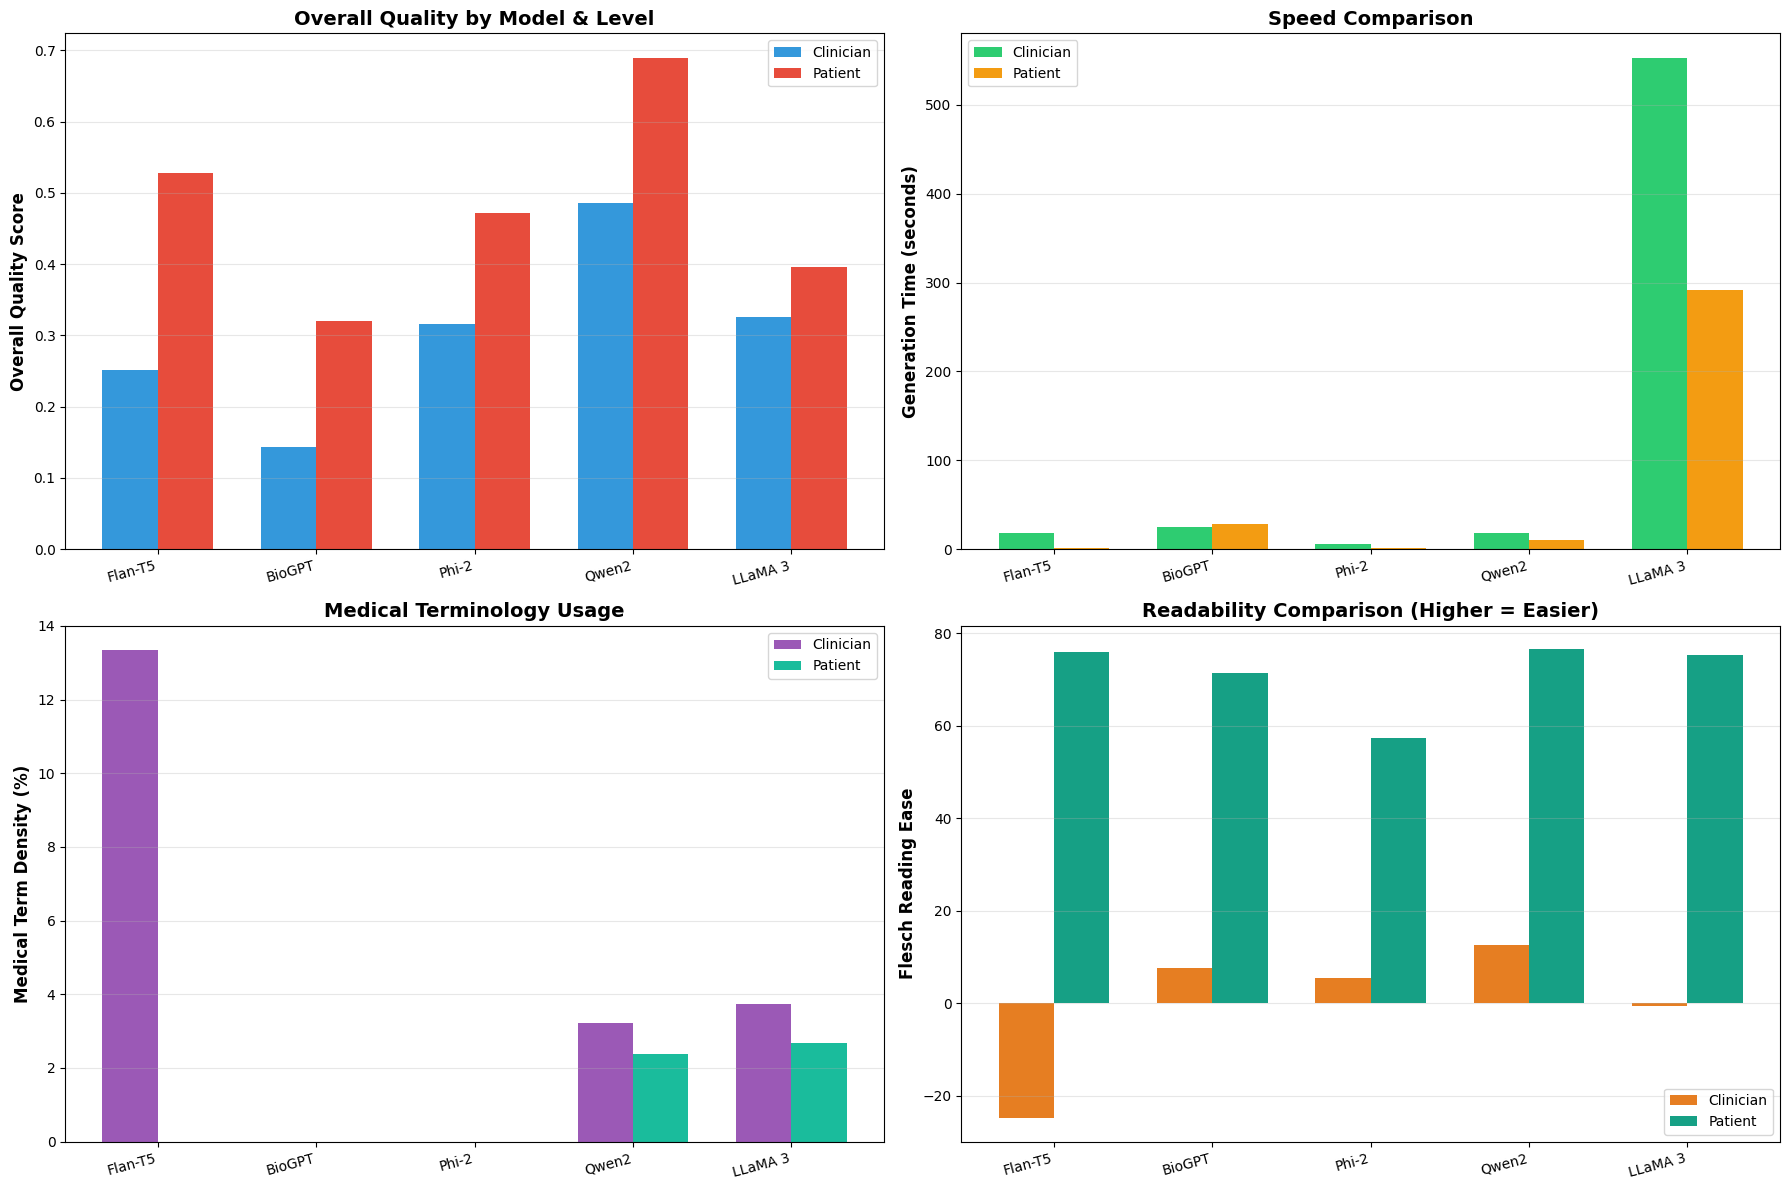

In [18]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 15: Visualization - Comparison Charts
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

print("Creating visualizations...\n")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

models = ["Flan-T5", "BioGPT", "Phi-2", "Qwen2", "LLaMA 3"]
model_keys = ["flant5", "biogpt", "phi2", "qwen2", "llama3"]

# 1. Overall Quality Comparison
ax = axes[0, 0]
clin_quality = [all_results[k]['clinician']['eval']['overall_quality'] for k in model_keys]
pat_quality = [all_results[k]['patient']['eval']['overall_quality'] for k in model_keys]

x = np.arange(len(models))
width = 0.35

ax.bar(x - width/2, clin_quality, width, label='Clinician', color='#3498db')
ax.bar(x + width/2, pat_quality, width, label='Patient', color='#e74c3c')
ax.set_ylabel('Overall Quality Score', fontsize=12, fontweight='bold')
ax.set_title('Overall Quality by Model & Level', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Generation Speed
ax = axes[0, 1]
clin_time = [all_results[k]['clinician']['eval']['generation_time'] for k in model_keys]
pat_time = [all_results[k]['patient']['eval']['generation_time'] for k in model_keys]

ax.bar(x - width/2, clin_time, width, label='Clinician', color='#2ecc71')
ax.bar(x + width/2, pat_time, width, label='Patient', color='#f39c12')
ax.set_ylabel('Generation Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Speed Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Medical Term Density
ax = axes[1, 0]
clin_medical = [all_results[k]['clinician']['eval']['medical_term_density'] for k in model_keys]
pat_medical = [all_results[k]['patient']['eval']['medical_term_density'] for k in model_keys]

ax.bar(x - width/2, clin_medical, width, label='Clinician', color='#9b59b6')
ax.bar(x + width/2, pat_medical, width, label='Patient', color='#1abc9c')
ax.set_ylabel('Medical Term Density (%)', fontsize=12, fontweight='bold')
ax.set_title('Medical Terminology Usage', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Readability
ax = axes[1, 1]
clin_read = [all_results[k]['clinician']['eval']['flesch_reading_ease'] for k in model_keys]
pat_read = [all_results[k]['patient']['eval']['flesch_reading_ease'] for k in model_keys]

ax.bar(x - width/2, clin_read, width, label='Clinician', color='#e67e22')
ax.bar(x + width/2, pat_read, width, label='Patient', color='#16a085')
ax.set_ylabel('Flesch Reading Ease', fontsize=12, fontweight='bold')
ax.set_title('Readability Comparison (Higher = Easier)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved: model_comparison.png")
plt.show()


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 16: Final Recommendation
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("FINAL RECOMMENDATION")
print("="*70)

# Calculate weighted scores
scores = []
for model_name, model_key in [("Flan-T5", "flant5"), ("BioGPT", "biogpt"), ("Phi-2", "phi2"), ("Qwen2", "qwen2"), ("LLaMA 3", "llama3")]:
    clin = all_results[model_key]['clinician']['eval']
    pat = all_results[model_key]['patient']['eval']

    # Weighted score: Quality (40%), Speed (30%), Medical (30%)
    avg_quality = (clin['overall_quality'] + pat['overall_quality']) / 2
    avg_speed_score = (min(1.0, 5/clin['generation_time']) + min(1.0, 5/pat['generation_time'])) / 2
    avg_medical_score = ((clin['medical_terms_count'] + pat['medical_terms_count']) / 2) / 10

    final_score = avg_quality * 0.4 + avg_speed_score * 0.3 + min(1.0, avg_medical_score) * 0.3

    scores.append({
        'model': model_name,
        'key': model_key,
        'score': final_score,
        'quality': avg_quality,
        'speed': avg_speed_score,
        'medical': avg_medical_score
    })

# Sort by score
scores.sort(key=lambda x: x['score'], reverse=True)

print("\nRANKED BY WEIGHTED SCORE")
print("   (Quality 40% + Speed 30% + Medical 30%)\n")

for i, s in enumerate(scores, 1):
    bar_length = int(s['score'] * 30)
    bar = "█" * bar_length
    print(f"{i}. {s['model']:12s} {s['score']:.3f} {bar}")
    print(f"   Quality: {s['quality']:.3f} | Speed: {s['speed']:.3f} | Medical: {s['medical']:.3f}\n")

# Recommendation
winner = scores[0]
print("="*70)
print("RECOMMENDED MODEL")
print("="*70)

print(f"\n**Primary Choice: {winner['model']}**\n")

clin_eval = all_results[winner['key']]['clinician']['eval']
pat_eval = all_results[winner['key']]['patient']['eval']

print(f"Strengths:")
print(f"  ✓ Best overall weighted score: {winner['score']:.3f}")
print(f"  ✓ Quality: {winner['quality']:.3f}")
print(f"  ✓ Avg generation time: {(clin_eval['generation_time'] + pat_eval['generation_time'])/2:.2f}s")
print(f"  ✓ Medical accuracy: {(clin_eval['medical_terms_count'] + pat_eval['medical_terms_count'])/2:.1f} terms")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)



FINAL RECOMMENDATION

RANKED BY WEIGHTED SCORE
   (Quality 40% + Speed 30% + Medical 30%)

1. Qwen2        0.517 ███████████████
   Quality: 0.587 | Speed: 0.390 | Medical: 0.550

2. Phi-2        0.435 █████████████
   Quality: 0.394 | Speed: 0.926 | Medical: 0.000

3. Flan-T5      0.378 ███████████
   Quality: 0.389 | Speed: 0.642 | Medical: 0.100

4. LLaMA 3      0.328 █████████
   Quality: 0.361 | Speed: 0.013 | Medical: 0.600

5. BioGPT       0.149 ████
   Quality: 0.232 | Speed: 0.189 | Medical: 0.000

RECOMMENDED MODEL

**Primary Choice: Qwen2**

Strengths:
  ✓ Best overall weighted score: 0.517
  ✓ Quality: 0.587
  ✓ Avg generation time: 13.95s
  ✓ Medical accuracy: 5.5 terms

ANALYSIS COMPLETE!


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 17: Export Results for Thesis
# ═══════════════════════════════════════════════════════════════════════════

import json

print("Exporting results for thesis...\n")

# Create export data
export_data = {
    "experiment_info": {
        "disease": top_disease,
        "confidence": float(top_confidence),
        "models_tested": 4,
        "total_explanations": 8
    },
    "results": {}
}

for model_name, model_key in [("Flan-T5", "flant5"), ("BioGPT", "biogpt"), ("Phi-2", "phi2"), ("Qwen2", "qwen2"), ("LLaMA 3", "llama3")]:
    export_data["results"][model_name] = {
        "clinician": {
            "text": all_results[model_key]['clinician']['text'],
            "metrics": all_results[model_key]['clinician']['eval']
        },
        "patient": {
            "text": all_results[model_key]['patient']['text'],
            "metrics": all_results[model_key]['patient']['eval']
        }
    }

# Save to JSON
with open('nlp_comparison_results.json', 'w') as f:
    json.dump(export_data, f, indent=2)

print("Results exported:")
print("   - nlp_comparison_results.json")
print("   - nlp_model_comparison.png")

print("\n" + "="*70)
print("READY FOR THESIS DOCUMENTATION!")
print("="*70)
print("\nUse the JSON file and visualizations in your:")
print("  • Results section")
print("  • Discussion section")
print("  • Model selection justification")


Exporting results for thesis...

Results exported:
   - nlp_comparison_results.json
   - nlp_model_comparison.png

READY FOR THESIS DOCUMENTATION!

Use the JSON file and visualizations in your:
  • Results section
  • Discussion section
  • Model selection justification
